# 第8讲 ParFlow水均衡计算

## 1. 为什么要计算水均衡？

水均衡是质量守恒定律在水文系统中的应用。对于一个给定的空间范围和时间区间，进入系统的水量减去离开系统的水量，应当等于系统内部储水量的变化。

计算水均衡可以检查模拟结果是否遵守水量守恒，帮助发现单位错误、时间错位、重启错误等问题。水量近似闭合是解释径流、蒸散发和储水变化的基本前提。

一般形式为：

$$
\text{输入水量}-\text{输出水量}=\text{储水量变化}
$$

在数值模拟结果中，由于求解误差、时间离散、空间离散、输出精度以及后处理方法等因素，等式两侧通常不会完全相等。因此引入水均衡残差：

$$
R=\text{输入水量}-\text{输出水量}-\text{储水量变化}
$$

当各项定义、单位、符号和时间区间均一致时，残差 $R$ 应接近零。

## 2. 确定水量计算范围

水均衡计算的第一步不是读取文件，而是确定水量计算范围，即明确“对哪一部分系统进行水量守恒检查”。在 ParFlow-CLM 中，可以采用两种不同的水量计算范围。

### 2.1 整个陆面—地下水系统

该水量计算范围包括大气降水到达地表以后涉及的全部陆面和地下水储水过程，例如冠层截留、积雪、地表积水、土壤水和地下水。相应的水均衡方程可以写为：

$$
P-ET-Q_{\mathrm{out}}=\Delta(S_{\mathrm{sub}}+S_{\mathrm{surf}}+S_{\mathrm{snow}}+S_{\mathrm{canopy}})
$$

其中：

- $P$：降水量；
- $ET$：总蒸散发量；
- $Q_{\mathrm{out}}$：流域出口径流量；
- $S_{\mathrm{sub}}$：地下和土壤孔隙中的储水量；
- $S_{\mathrm{surf}}$：地表积水量；
- $S_{\mathrm{snow}}$：积雪水当量；
- $S_{\mathrm{canopy}}$：冠层截留水量。

这种计算能够反映整个陆面水文系统的收支，但要求获得冠层和积雪等 CLM 状态量。

### 2.2 只针对 ParFlow 水文域

如果水量计算范围只包括 ParFlow 求解的地表水和地下水，则输入项不再直接使用气象降水，而应使用 CLM 传递给 ParFlow 的净水通量：

$$
F_{\mathrm{CLM\rightarrow PF}}-Q_{\mathrm{out}}=\Delta(S_{\mathrm{sub}}+S_{\mathrm{surf}})
$$

其中 $F_{\mathrm{CLM\rightarrow PF}}$ 是 CLM 与 ParFlow 之间的耦合通量。它综合考虑了到达土壤表面的水、裸土蒸发、植被蒸腾以及灌溉等过程。概念上可以写为：

$$
F_{\mathrm{CLM\rightarrow PF}}=q_{\mathrm{infl}}+q_{\mathrm{irrig}}-q_{\mathrm{tran}}
$$

这里需要特别注意：

- $q_{\mathrm{infl}}$ 不是原始气象降水；
- 降水可能先被冠层截留，也可能形成积雪；
- 到达土壤表面的水可以是穿透雨或融雪；
- $q_{\mathrm{infl}}$ 中已经考虑了地表裸土蒸发的影响；
- 如果使用 CLM 传给 ParFlow 的净通量，就不能再重复扣除同一部分蒸发量。

本课程后续的数值演示将优先采用这一水量计算范围，因为它最适合检查 ParFlow 水文域及其与 CLM 的耦合是否满足质量守恒。

## 3. 本课程例子的水均衡条件

`parflow-clm/model_run.py` 中的主要设置如下：

- 水平网格数为 $98\times61$；
- 垂向共有 10 层；
- 水平网格分辨率为 $dx=dy=961.72\ \mathrm{m}$；
- 模拟时长为 72 小时；
- 时间步长和结果输出间隔均为 1 小时；
- 侧边界和底边界为零通量边界；
- 顶部边界采用运动波地表径流条件；
- 模型采用真实流域边界，矩形网格中包含非活动网格；
- 模型使用可变垂向网格；
- CLM 使用三维气象驱动数据。

由于侧边界和底边界均没有水量交换，在没有井、河流边界或其他源汇项的情况下，ParFlow 水量计算范围的主要输入为 CLM 传给 ParFlow 的净通量，主要输出为流域出口的地表径流。

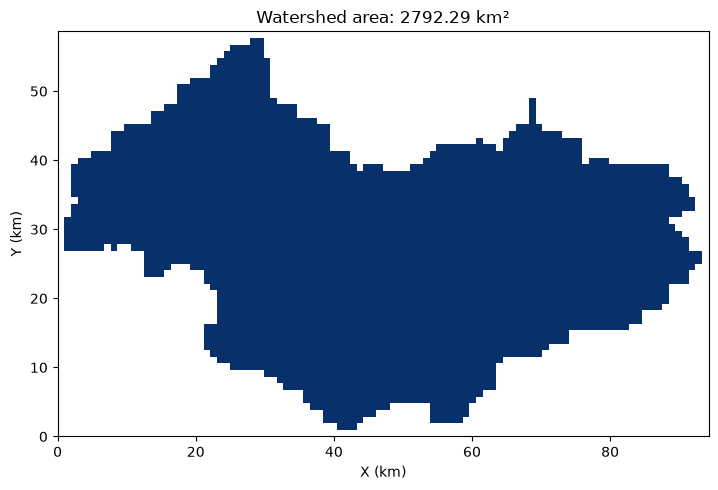

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from parflow.tools.io import read_pfb

run_name = "PF_CLM_Example"
output_dir = Path("outputs") / run_name
nx, ny, nz = 98, 61, 10
dx = dy = 961.72
dz = 200 * np.array([1.5, 0.5, 0.25, 0.125, 0.05, 0.025, 0.005, 0.003, 0.0015, 0.0005])
dt, nt = 1.0, 72

mask_3d = read_pfb(output_dir / f"{run_name}.out.mask.pfb")
mask = np.where(mask_3d[-1] > 0, 1.0, np.nan)
area = np.isfinite(mask).sum() * dx * dy / 1e6

plt.figure(figsize=(9, 5))
plt.imshow(mask, origin="lower", cmap="Blues",vmin=0,vmax=1, extent=[0, nx*dx/1000, 0, ny*dy/1000])
plt.title(f"Watershed area: {area:.2f} km²")
plt.xlabel("X (km)")
plt.ylabel("Y (km)")
plt.tight_layout()
plt.show()

## 4. 水均衡所需组分

### 4.1 地下储水量

地下储水量包括土壤和地下含水层孔隙中的水，以及正压力产生的可压缩储水量。公式中记作 $S_{\mathrm{sub}}$，单位为 $\mathrm{m^3}$。

In [2]:
import parflow as pf
import parflow.tools.hydrology as hydro

pressure = pf.read_pfb_sequence(sorted(output_dir.glob(f"{run_name}.out.press.*.pfb")))
saturation = pf.read_pfb_sequence(sorted(output_dir.glob(f"{run_name}.out.satur.*.pfb")))
porosity = read_pfb(output_dir / f"{run_name}.out.porosity.pfb")
specific_storage = read_pfb(output_dir / f"{run_name}.out.specific_storage.pfb")

# 网格尺寸和层厚均为 m，函数计算各网格储水体积，求和后单位为 m³
subsurface_storage = np.array([hydro.calculate_subsurface_storage(
    porosity, p, s, specific_storage, dx, dy, dz, mask_3d).sum()
    for p, s in zip(pressure, saturation)])

print(f"初始地下储水量：{subsurface_storage[0]:.3e} m³")
print(f"最终地下储水量：{subsurface_storage[-1]:.3e} m³")

初始地下储水量：4.477e+11 m³
最终地下储水量：4.476e+11 m³


### 4.2 地表储水量

地表储水量表示流域表面的积水，只计算活动网格中的正压力。公式中记作 $S_{\mathrm{surf}}$，单位为 $\mathrm{m^3}$。

In [3]:
# 正压力（m）乘网格面积（m²），求和后单位为 m³
surface_storage = np.array([
    hydro.calculate_surface_storage(p, dx, dy, mask_3d).sum()
    for p in pressure])

print(f"初始地表储水量：{surface_storage[0]:.3e} m³")
print(f"最终地表储水量：{surface_storage[-1]:.3e} m³")

初始地表储水量：1.043e+08 m³
最终地表储水量：5.474e+07 m³


### 4.3 储水量变化

储水量变化是相邻两个时刻地下储水量与地表储水量之和的差值。公式中记作 $\Delta S_i=(S_{\mathrm{sub},i}+S_{\mathrm{surf},i})-(S_{\mathrm{sub},i-1}+S_{\mathrm{surf},i-1})$，单位为 $\mathrm{m^3}$。

In [4]:
# 两类储水量均为 m³，相邻状态相减后单位仍为 m³
total_storage = subsurface_storage + surface_storage
storage_change = np.diff(total_storage)

print(f"72小时总储水量变化：{storage_change.sum():.3e} m³")

72小时总储水量变化：-1.925e+08 m³


### 4.4 降水量

降水量来自 `APCP` 气象驱动文件，表示每个时间步落在流域范围内的降水体积。公式中记作 $P_i$，单位为 $\mathrm{m^3}$。

In [5]:
apcp_files = sorted(Path("forcing").glob("E5L.APCP.*.pfb"))
apcp = np.concatenate([read_pfb(f) for f in apcp_files])
# APCP 单位为 mm/s；乘 3.6 转为 m/h，再乘网格面积（m²）和 dt（h）得到 m³
precipitation = np.nansum(apcp * mask, axis=(1, 2)) * dx * dy * dt * 3.6

print(f"72小时降水量：{precipitation.sum():.3e} m³")

72小时降水量：0.000e+00 m³


### 4.5 蒸散发量

蒸散发量使用 CLM 输出的 `qflx_evap_tot`。官方手册将该变量称为总蒸发通量，本讲义将其作为整个陆面系统的总蒸散发项。公式中记作 $ET_i$，单位为 $\mathrm{m^3}$。

`clm_output.*.C.pfb` 中各层含义如下：

| 索引 | 变量名 | 官方含义 | 原始单位 |
|---:|---|---|---|
| 0 | `eflx_lh_tot` | 总潜热通量 | W/m² |
| 1 | `eflx_lwrad_out` | 向外长波辐射通量 | W/m² |
| 2 | `eflx_sh_tot` | 总感热通量 | W/m² |
| 3 | `eflx_soil_grnd` | 地面热通量 | W/m² |
| 4 | `qflx_evap_tot` | 总蒸发通量 | mm/s |
| 5 | `qflx_evap_grnd` | 地表蒸发通量（不含凝结） | mm/s |
| 6 | `qflx_evap_soi` | 土壤蒸发通量 | mm/s |
| 7 | `qflx_evap_veg` | 植被蒸发通量 | mm/s |
| 8 | `qflx_tran_veg` | 植被蒸腾通量 | mm/s |
| 9 | `qflx_infl` | 土壤入渗通量 | mm/s |
| 10 | `swe_out` | 积雪水当量 | mm |
| 11 | `t_grnd` | 地表温度 | K |
| 12 | `qflx_qirr` | 灌溉通量占位层；本例未启用灌溉 | mm/s |
| 13 | `t_soil` | CLM 第 1 层土壤温度 | K |
| 14 | `t_soil` | CLM 第 2 层土壤温度 | K |
| 15 | `t_soil` | CLM 第 3 层土壤温度 | K |
| 16 | `t_soil` | CLM 第 4 层土壤温度 | K |

总蒸散发通量由土壤蒸发、冠层蒸发和植被蒸腾三部分组成。

在本例的 CLM 输出中，植被蒸发通量 `qflx_evap_veg` 表示冠层蒸发与植被蒸腾之和。因此，总蒸散发通量 `qflx_evap_tot` 等于土壤蒸发通量 `qflx_evap_soi` 与植被蒸发通量 `qflx_evap_veg` 之和。

In [6]:
clm_files = sorted(output_dir.glob(f"{run_name}.out.clm_output.*.C.pfb"))
clm_output = pf.read_pfb_sequence(clm_files)
# qflx_evap_tot 单位为 mm/s；乘 3.6 转为 m/h，再乘网格面积（m²）和 dt（h）得到 m³
evapotranspiration = np.nansum(clm_output[:, 4] * mask, axis=(1, 2)) * dx * dy * dt * 3.6

print(f"72小时蒸散发量：{evapotranspiration.sum():.3e} m³")

72小时蒸散发量：3.015e+07 m³


### 4.6 CLM–ParFlow 净水通量

该项表示 CLM 在每个时间步传给 ParFlow 的净水量，正值表示进入 ParFlow，负值表示水分损失。公式中记作 $F_{\mathrm{CLM\rightarrow PF},i}$，单位为 $\mathrm{m^3}$。

In [7]:
evaptrans = pf.read_pfb_sequence(sorted(output_dir.glob(f"{run_name}.out.evaptrans.*.pfb")))
# evaptrans 单位为 1/h；函数乘网格体积后得到 m³/h，再乘 dt（h）得到 m³
clm_to_pf = np.array([
    hydro.calculate_evapotranspiration(et, dx, dy, dz, mask_3d).sum() * dt
    for et in evaptrans])

print(f"72小时CLM–ParFlow净水量：{clm_to_pf.sum():.3e} m³")

72小时CLM–ParFlow净水量：-2.994e+07 m³


### 4.7 流域出口径流量

流域出口径流量是每个时间步通过真实流域边界流出的地表水量。公式中记作 $Q_{\mathrm{out},i}$，单位为 $\mathrm{m^3}$。

In [8]:
slope_x = read_pfb(output_dir / f"{run_name}.out.slope_x.pfb")
slope_y = read_pfb(output_dir / f"{run_name}.out.slope_y.pfb")
mannings = read_pfb(output_dir / f"{run_name}.out.mannings.pfb")

# 函数返回流域边界出流率（m³/h），乘 dt（h）得到该时间区间的出流水量（m³）
outflow = np.array([hydro.calculate_overland_flow(
    p, slope_x, slope_y, mannings, dx, dy,
    flow_method="OverlandKinematic", mask=mask_3d) * dt
    for p in pressure[1:]])

print(f"72小时流域出口径流量：{outflow.sum():.3e} m³")

72小时流域出口径流量：1.630e+08 m³


### 4.8 其他水量项

其他水量项包括底部和侧边界通量、井以及人工源汇，以净输入为正，公式中记作 $F_{\mathrm{other},i}$。本例中这些水量项均为零，因此后面的公式将其省略。单位为 $\mathrm{m^3}$。

In [9]:
# 这里直接使用每个小时区间的水量（m³），本例三项均为零
bottom_flux = side_flux = well_flux = 0.0
print(f"其他水量项：{bottom_flux + side_flux + well_flux:.1f} m³")

其他水量项：0.0 m³


## 5. 水均衡计算
对于整个陆面系统，第 $i$ 个时间区间的残差定义为：

$$
R_i=P_i-ET_i-Q_{\mathrm{out},i}-\Delta S_i
$$

对于 ParFlow 水量计算范围，残差定义为：

$$
R_i=F_{\mathrm{CLM\rightarrow PF},i}-Q_{\mathrm{out},i}-\Delta S_i
$$
本例有 73 个状态时刻（0–72 h）和 72 个小时区间。第 $i$ 小时（$i=1,2,\ldots,72$）的水均衡对应时间区间 $(i-1,i]$，其中通量组分 $P_i$、$ET_i$ 和 $F_{\mathrm{CLM\rightarrow PF},i}$ 使用第 $i$ 个通量记录，$Q_{\mathrm{out},i}$ 使用第 $i$ 小时末的压力状态计算，储水量变化使用 $\Delta S_i=S_i-S_{i-1}$。下面同时计算两种水均衡，并比较二者的差异。

### 5.1 各组分时间序列

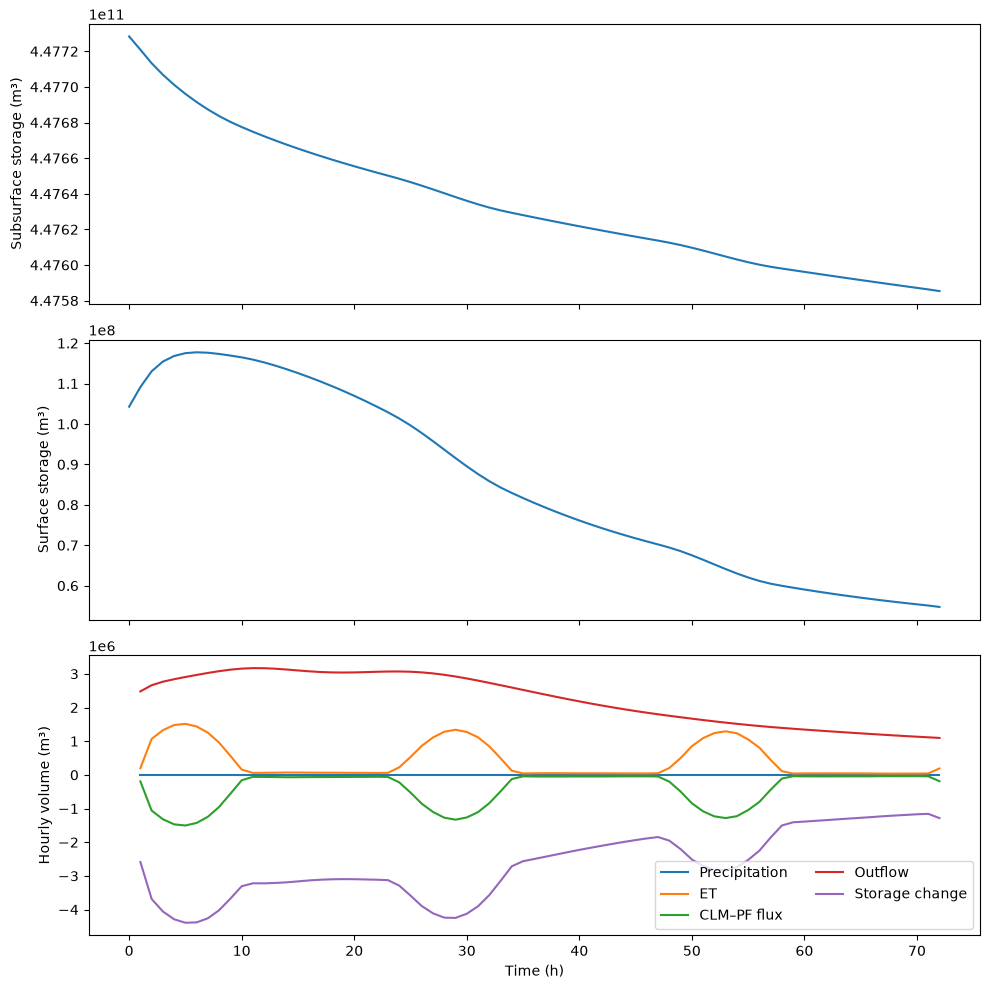

In [12]:
time_state = np.arange(nt + 1)
time = np.arange(1, nt + 1)
other = np.full(nt, bottom_flux + side_flux + well_flux)

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
axes[0].plot(time_state, subsurface_storage)
axes[0].set_ylabel("Subsurface storage (m³)")
axes[1].plot(time_state, surface_storage)
axes[1].set_ylabel("Surface storage (m³)")
axes[2].plot(time, precipitation, label="Precipitation")
axes[2].plot(time, evapotranspiration, label="ET")
axes[2].plot(time, clm_to_pf, label="CLM–PF flux")
axes[2].plot(time, outflow, label="Outflow")
axes[2].plot(time, storage_change, label="Storage change")
# axes[2].plot(time, other, label="Other")
axes[2].set_xlabel("Time (h)")
axes[2].set_ylabel("Hourly volume (m³)")
axes[2].legend(ncol=2)
plt.tight_layout()
plt.show()

### 5.2 水均衡计算与结果表

方法一使用降水量和 CLM 总蒸散发量，方法二使用 CLM–ParFlow 净水量。两种方法采用相同的出口径流量和储水量变化。

In [22]:
import pandas as pd

balance_land = precipitation - evapotranspiration + other - outflow - storage_change
balance_pf = clm_to_pf + other - outflow - storage_change
balance_difference = balance_land - balance_pf
balance_land_percent = balance_land / total_storage[1:] * 100
balance_pf_percent = balance_pf / total_storage[1:] * 100

result = pd.DataFrame({
    "时间（h）": time,
    "地下储水量（m³）": subsurface_storage[1:],
    "地表储水量（m³）": surface_storage[1:],
    "储水量变化（m³）": storage_change,
    "降水量（m³）": precipitation,
    "蒸散发量（m³）": evapotranspiration,
    "CLM–ParFlow净水量（m³）": clm_to_pf,
    "出口径流量（m³）": outflow,
    # "其他水量（m³）": other,
    "陆面系统水均衡（m³）": balance_land,
    "陆面系统水均衡百分比（%）": balance_land_percent,
    "ParFlow水均衡（m³）": balance_pf,
    "ParFlow水均衡百分比（%）": balance_pf_percent,
    "两种方法差值（m³）": balance_difference
})

print(f"陆面系统最大绝对水均衡百分比：{np.max(np.abs(balance_land_percent)):.3e}%")
print(f"ParFlow最大绝对水均衡百分比：{np.max(np.abs(balance_pf_percent)):.3e}%")

陆面系统最大绝对水均衡百分比：2.062e-05%
ParFlow最大绝对水均衡百分比：1.971e-05%


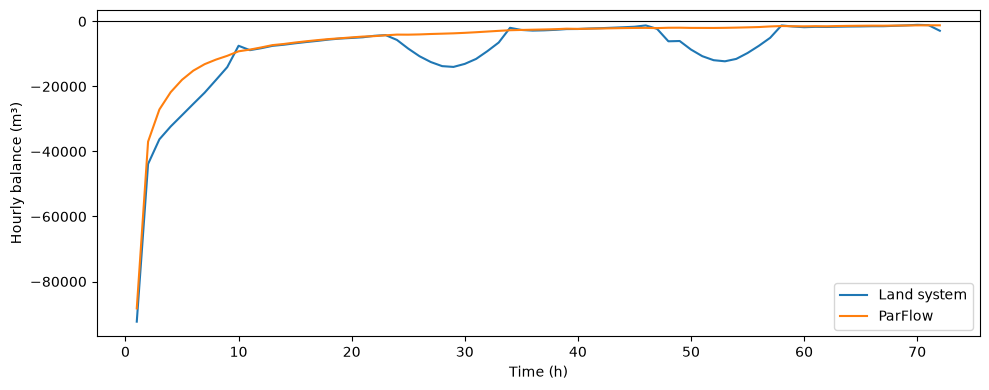

,时间（h）,地下储水量（m³）,地表储水量（m³）,储水量变化（m³）,降水量（m³）,蒸散发量（m³）,CLM–ParFlow净水量（m³）,出口径流量（m³）,陆面系统水均衡（m³）,陆面系统水均衡百分比（%）,ParFlow水均衡（m³）,ParFlow水均衡百分比（%）,两种方法差值（m³）
0,1,4.477209e+11,1.091292e+08,-2.587285e+06,0.0,1.998329e+05,-1.957464e+05,2.479794e+06,-92341.855788,-2.061985e-05,-88255.346630,-1.970733e-05,-4086.509158
1,2,4.477133e+11,1.130360e+08,-3.684898e+06,0.0,1.067328e+06,-1.060460e+06,2.661420e+06,-43849.985983,-9.791739e-06,-36981.578702,-8.258018e-06,-6868.407280
2,3,4.477068e+11,1.154370e+08,-4.056870e+06,0.0,1.326694e+06,-1.317515e+06,2.766445e+06,-36268.431860,-8.098845e-06,-27089.431075,-6.049148e-06,-9179.000785
3,4,4.477012e+11,1.168192e+08,-4.288404e+06,0.0,1.480039e+06,-1.469483e+06,2.840682e+06,-32317.158237,-7.216584e-06,-21761.625806,-4.859480e-06,-10555.532431
4,5,4.476961e+11,1.175138e+08,-4.391588e+06,0.0,1.514348e+06,-1.503459e+06,2.906089e+06,-28848.698704,-6.442122e-06,-17959.796957,-4.010552e-06,-10888.901747
5,6,4.476915e+11,1.177295e+08,-4.379691e+06,0.0,1.437284e+06,-1.427064e+06,2.967771e+06,-25364.344306,-5.664096e-06,-15144.798354,-3.381976e-06,-10219.545952
6,7,4.476873e+11,1.176233e+08,-4.257180e+06,0.0,1.252570e+06,-1.243805e+06,3.026535e+06,-21924.480458,-4.895989e-06,-13159.633029,-2.938698e-06,-8764.847428
7,8,4.476836e+11,1.173157e+08,-4.017620e+06,0.0,9.556506e+05,-9.493834e+05,3.079990e+06,-18020.617251,-4.024247e-06,-11753.410011,-2.624695e-06,-6267.207240
8,9,4.476803e+11,1.169185e+08,-3.674210e+06,0.0,5.640776e+05,-5.606051e+05,3.124194e+06,-14061.750910,-3.140205e-06,-10589.216983,-2.364735e-06,-3472.533927
9,10,4.476775e+11,1.164817e+08,-3.306614e+06,0.0,1.588935e+05,-1.606015e+05,3.155218e+06,-7497.520425,-1.674324e-06,-9205.606892,-2.055769e-06,1708.086467


In [23]:
plt.figure(figsize=(10, 4))
plt.plot(time, balance_land, label="Land system")
plt.plot(time, balance_pf, label="ParFlow")
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Time (h)")
plt.ylabel("Hourly balance (m³)")
plt.legend()
plt.tight_layout()
plt.show()

with pd.option_context("display.max_rows", None):
    display(result)

## 6. 为什么水均衡不是严格闭合？

对于 ParFlow 水量计算范围，第 $i$ 个时间区间的残差为：

$$
R_i=F_{\mathrm{CLM\rightarrow PF},i}-Q_{\mathrm{out},i}-\Delta S_i
$$

水均衡百分比使用残差除以该时刻的地下与地表总储水量：

$$
\varepsilon_i=\frac{R_i}{S_{\mathrm{sub},i}+S_{\mathrm{sur},i}}\times100\%
$$

本算例 72 个时间区间中，ParFlow 水均衡百分比的最大绝对值约为 $1.971\times10^{-5}\%$，非常接近零，因此可以认为水量近似闭合，但不能表述为严格闭合。残差主要来自时间离散、边界径流后处理和模型求解中的数值误差。

**在真实流域模拟中，水均衡通常不会完美闭合，可以通过water balance 百分比判断结果是否可以接受。**

## 7. 为什么两种方法会有差异？

两种方法采用了不同的水量计算范围。第一种方法使用降水和 CLM 总蒸散发描述整个陆面系统，第二种方法使用 CLM 实际传给 ParFlow 的净水通量描述 ParFlow 水量计算范围。

两种残差之差为：

$$
R_{\mathrm{land}}-R_{\mathrm{PF}}=P-ET-F_{\mathrm{CLM\rightarrow PF}}
$$

降水在进入 ParFlow 前会经过冠层和积雪等 CLM 储水环节，而 CLM 总蒸散发也包含冠层蒸发。因此，降水减去总蒸散发通常不等于 CLM–ParFlow 净水通量。它们之间的关系为：

$$
F_{\mathrm{CLM\rightarrow PF}}=P-ET-\Delta S_{\mathrm{CLM}}
$$

所以，两种方法的差异主要反映 CLM 冠层和积雪等储水的变化。